In [1]:
import seaborn as sns
import pandas as pd
import json
import os
import re
sns.set_style('darkgrid')

In [2]:
src_dir = '/home/luca/Workspace/eye_gaze_injection/models/complexity'
model_dirs = [os.path.join(src_dir, model_name) for model_name in os.listdir(src_dir)]

In [3]:
def load_trainer_state(model_dir):
    trainer_state_path = os.path.join(model_dir, 'trainer_state.json')
    with open(trainer_state_path, 'r') as src_file:
        trainer_state = json.load(src_file)
    return trainer_state

In [4]:
trainer_states = {}
for model_dir in model_dirs:
    try:
        trainer_states[model_dir] = load_trainer_state(model_dir)
    except:
        pass

In [5]:
def parse_log_history_eval_metrics(log_history):
    logs_dict = {'epoch': [], 'metric':[], 'score':[]}
    for el in log_history:
        if 'eval_loss' in el:
            for metric in ['mae', 'spearmanr']:
                logs_dict['epoch'].append(el['epoch'])
                logs_dict['metric'].append(metric)
                logs_dict['score'].append(el[f'eval_{metric}'])
    return pd.DataFrame.from_dict(logs_dict)

In [6]:
metrics_dfs = []
for model_dir, trainer_state in trainer_states.items():
    user_id = re.findall(r'pp(\d*)', model_dir)[0]
    # lr = re.findall(r'_lr(.*)$', model_dir)[0]
    metrics_df = parse_log_history_eval_metrics(trainer_state['log_history'])
    # metrics_df['learning_rate'] = lr
    metrics_df['user'] = user_id
    metrics_df['model'] = model_dir.split('/')[-1]
    freeze = '_'.join(model_dir.split('/')[-1].split('_')[-2:]) 
    metrics_df['freeze'] = freeze if 'pp' not in freeze else 'full'
    metrics_dfs.append(metrics_df)
metrics_dfs = pd.concat(metrics_dfs, axis=0)

In [7]:
hue_order = ['full', 'last_3', 'last_2', 'regressor_only']

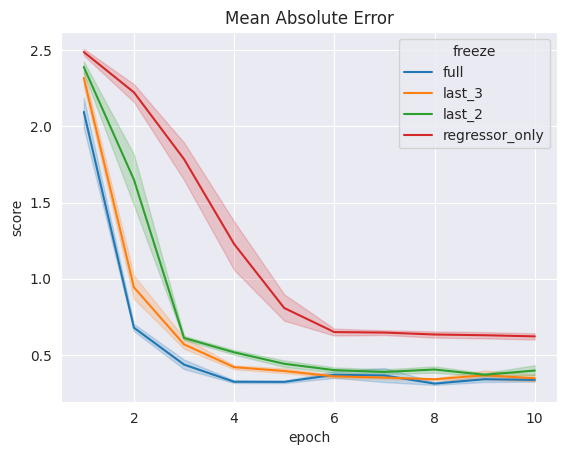

In [8]:
sns.lineplot(data=metrics_dfs[metrics_dfs['metric']=='mae'], x='epoch', y='score', hue='freeze', hue_order=hue_order).set_title('Mean Absolute Error');

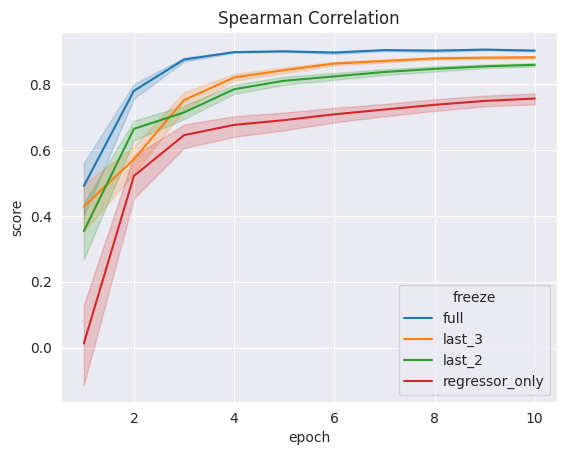

In [9]:
sns.lineplot(data=metrics_dfs[metrics_dfs['metric']=='spearmanr'], x='epoch', y='score', hue='freeze', hue_order=hue_order).set_title('Spearman Correlation');